In [1]:
%load_ext autoreload
%autoreload 2
import tqdm, tqdm.notebook
tqdm.tqdm = tqdm.notebook.tqdm  # notebook-friendly progress bars
from pathlib import Path
import numpy as np

from hloc import extract_features1, match_features2, reconstruction, visualization, pairs_from_exhaustive
from hloc.visualization import plot_images, read_image
from hloc.utils import viz_3d, viz_3d_1
import h5py
from hloc.match_features1 import get_image


/home/robotics/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
images = Path('datasets/doppelgangers')
outputs = Path('outputs/demo/')

In [10]:
!rm -rf $outputs

In [11]:
sfm_pairs = outputs / 'pairs-sfm.txt'
loc_pairs = outputs / 'pairs-loc.txt'
sfm_dir = outputs / 'sfm'
features = outputs / 'features.h5'
feature_raw_ref = outputs / 'features_raw.h5'
matches = outputs / 'matches.h5'
dict_keypoints_index_query = outputs / 'dict_keypoints_index_query.h5'
# dict_keypoints_index_map = outputs / 'dict_keypoints_index_map.h5'

2 mapping images


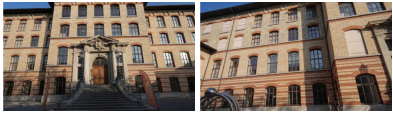

In [12]:
references = [p.relative_to(images).as_posix() for p in (images).iterdir()]
print(len(references), "mapping images")
plot_images([read_image(images / r) for r in references], dpi=25)

In [13]:
references

['map_doppelgangers1.jpg', 'query_doppelgangers1.jpg']

In [14]:
feature_conf = extract_features1.confs['superpoint_aachen']
extract_features1.main(feature_conf, images, image_list=references, feature_path=features, dict_keypoints_index=dict_keypoints_index_query, feature_raw_path = feature_raw_ref)

Loaded SuperPoint model


  0%|          | 0/2 [00:00<?, ?it/s]

[2026/06/15 23:38:00 hloc INFO] Copied outputs/demo/features.h5 to outputs/demo/features_raw.h5 for roma preprocessing.
[2026/06/15 23:38:00 hloc INFO] Finished exporting features.


PosixPath('outputs/demo/features.h5')

In [15]:
pairs_from_exhaustive.main(sfm_pairs, image_list=references)

[2026/06/15 23:38:02 hloc INFO] Found 1 pairs.


In [16]:
matcher_conf = match_features2.confs['lightglue+dkm']['hloc']
match_features2.main(matcher_conf, sfm_pairs, features=features, matches=matches, dict_keypoints_index_query=dict_keypoints_index_query,dict_keypoints_index_map=dict_keypoints_index_query, feature_path_raw_ref=feature_raw_ref, overwrite=True)


---start lg

----pairs path: outputs/demo/pairs-sfm.txt
LightGlue: Loading weights from /home/robotics/VisualLocalization/NAMTT/crocodl-benchmark/external/hloc/third_party/Lightglue/superpoint_lightglue_v0-1_arxiv.pth


  0%|          | 0/1 [00:00<?, ?it/s]

[2026/06/15 23:38:04 hloc INFO] Matching local features with configuration:
{'model': {'dist_threshold': 2.0,
           'max_keypoints': 4096,
           'name': 'dkm',
           'resize_max': 512,
           'weight_mode': 'indoor'},
 'model2': {'features': 'superpoint',
            'name': 'lightglue',
            'preprocessing': {'resize_force': True, 'resize_max': 512}},
 'output': 'matches-superglue-dkm'}


data0['keypoints']: torch.Size([1, 1451, 2]), data1['keypoints'].shape: torch.Size([1, 1253, 2])
keypts0.shape: torch.Size([1, 1451, 2]), keypts1.shape: torch.Size([1, 1253, 2])


/home/robotics/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/robotics/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


...

/home/robotics/.local/lib/python3.10/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4382.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


shape dists_4_sp0 torch.Size([4011, 1])
shape dists_4_sp1 torch.Size([4011, 1])
len: 1451, shape0: ()
kpt0.shape(1, 5262, 2), kpt1.shape(1, 5064, 2)
old_list_matches0_f.shape: (5262, 1)
old_list_matching_scores0_f.shape: (5262, 1)
sub_____________looooppppppppp


[2026/06/15 23:38:05 hloc INFO] Finished exporting matches.


looooppppppppppppppppppppppppp
count_keypoints_loss: 0


PosixPath('outputs/demo/matches.h5')

In [33]:
# read the h5 file keypoints
path_h5_keypoints = "/home/robotics/VisualLocalization/DAT/crocodl-benchmark/external/hloc/outputs/demo/features.h5"
map_key = 'map_doppelgangers1.jpg'
# map_key = 'query_doppelgangers1.jpg'
image_path = images / map_key
keypoints_map = None
with h5py.File(path_h5_keypoints, 'r') as f:
    print(list(f[map_key].keys()))
    keypoints_map = f[map_key]['keypoints'][:][0]
    

['descriptors', 'image', 'image_path', 'image_size', 'keypoints', 'scores']


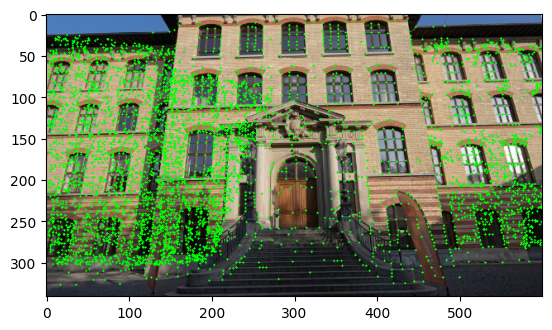

In [34]:
import matplotlib.pyplot as plt
import cv2
img_t = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
for x, y in keypoints_map:
    cv2.circle(img_t, (x, y), 1, (0, 255, 0), -1)
plt.imshow(img_t)
plt.show()

In [10]:
# # read the h5 file keypoints
# path_h5_keypoints = "/home/robotics/VisualLocalization/DAT/crocodl-benchmark/external/hloc/outputs/demo/features.h5"
# with h5py.File(path_h5_keypoints, 'r') as f:
#     print(f['17295357_9106075285.jpg']['keypoints'])

# read the h5 file keypoints
path_h5_keypoints = "/home/robotics/VisualLocalization/DAT/crocodl-benchmark/external/hloc/outputs/demo/features.h5"
with h5py.File(path_h5_keypoints, 'r') as f:
    print(f.keys())
    # print(f['query_12.jpg']['keypoints'])


<KeysViewHDF5 ['map_doppelgangers1.jpg', 'query_doppelgangers1.jpg']>


In [11]:
# read the h5 file matches
path_h5_matches = "/home/robotics/VisualLocalization/DAT/crocodl-benchmark/external/hloc/outputs/demo/matches.h5"
with h5py.File(path_h5_matches, 'r') as f:
    for key in f.keys():
        for sub_key in f[key].keys():
            print(f"key: {key}, sub_key: {sub_key}")
            print(f[key][sub_key]['matches0'])
        break

key: map_doppelgangers1.jpg, sub_key: query_doppelgangers1.jpg
<HDF5 dataset "matches0": shape (5275, 1), type "<i8">


In [12]:
path_h5_matches = "/home/robotics/VisualLocalization/DAT/crocodl-benchmark/external/hloc/outputs/demo/matches.h5"
count_matches = 0
with h5py.File(path_h5_matches, 'r') as f:
    matches0_test = f['map_doppelgangers1.jpg']['query_doppelgangers1.jpg']['matches0'][:]
    scores0_test = f['map_doppelgangers1.jpg']['query_doppelgangers1.jpg']['matching_scores0'][:]
    for b in matches0_test:
        for val in b:
            if val > 4649:
                print("sai r")
            else:
                count_matches+=1
count_matches

sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai r
sai 

4848

In [13]:
import matplotlib.pyplot as plt
import cv2
from glob import glob

In [14]:
def get_patch_bbox(H, W, patch_id):
    """Trả về tọa độ (x_min, y_min, x_max, y_max) của patch dựa trên ID."""
    h_half, w_half = H // 2, W // 2
    
    if patch_id == 0:   # Full ảnh
        return 0, 0, W, H
    elif patch_id == 1: # Góc trên - trái
        return 0, 0, w_half, h_half
    elif patch_id == 2: # Góc trên - phải
        return w_half, 0, W, h_half
    elif patch_id == 3: # Góc dưới - trái
        return 0, h_half, w_half, H
    elif patch_id == 4: # Góc dưới - phải
        return w_half, h_half, W, H
    else:
        raise ValueError("ID chỉ được nằm trong khoảng 0 đến 4")

def draw_custom_matches(img1, img2, kpts1, kpts2, matches, id1=0, id2=0):
    """
    Vẽ matches giữa 2 ảnh dựa trên id1 và id2.
    """
    H1, W1 = img1.shape[:2]
    H2, W2 = img2.shape[:2]
    
    # Lấy tọa độ vùng (bbox) cần giữ lại cho từng ảnh
    x1_min, y1_min, x1_max, y1_max = get_patch_bbox(H1, W1, id1)
    x2_min, y2_min, x2_max, y2_max = get_patch_bbox(H2, W2, id2)
    
    # --- 1. TẠO CANVAS TRẮNG ---
    max_h = max(H1, H2)
    total_w = W1 + W2
    canvas = np.ones((max_h, total_w, 3), dtype=np.uint8) * 255
    
    # --- 2. DÁN ẢNH 1 VÀ VẼ KHUNG ---
    canvas[y1_min:y1_max, x1_min:x1_max] = img1[y1_min:y1_max, x1_min:x1_max]
    cv2.rectangle(canvas, (x1_min, y1_min), (x1_max, y1_max), (0, 0, 255), 2)
    cv2.putText(canvas, f"img1 (id={id1})", (x1_min + 10, y1_min + 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    # --- 3. DÁN ẢNH 2 VÀ VẼ KHUNG ---
    # Tọa độ X trên canvas phải cộng thêm W1 (vì ảnh 2 nằm bên phải)
    canvas[y2_min:y2_max, W1 + x2_min : W1 + x2_max] = img2[y2_min:y2_max, x2_min:x2_max]
    cv2.rectangle(canvas, (W1 + x2_min, y2_min), (W1 + x2_max, y2_max), (0, 0, 255), 2)
    cv2.putText(canvas, f"img2 (id={id2})", (W1 + x2_min + 10, y2_min + 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    # --- 4. VẼ KEYPOINTS VÀ MATCHES ---
    m_cols = matches.shape[1]
    
    # Vẽ keypoints cho ảnh 2 (chỉ vẽ nếu nằm trong bbox của id2)
    for pt in kpts2:
        x2, y2 = int(pt[0]), int(pt[1])
        if x2_min <= x2 < x2_max and y2_min <= y2 < y2_max:
            cv2.circle(canvas, (x2 + W1, y2), 3, (0, 0, 0), -1)

    # Lặp qua từng keypoint của ảnh 1
    for i, pt1 in enumerate(kpts1):
        x1, y1 = int(pt1[0]), int(pt1[1])
        
        # Chỉ xử lý nếu keypoint 1 nằm trong bbox của id1
        if x1_min <= x1 < x1_max and y1_min <= y1 < y1_max:
            cv2.circle(canvas, (x1, y1), 1, (0, 0, 0), -1)
            
            for j in range(m_cols):
                idx2 = matches[i, j]
                if idx2 != -1:
                    x2, y2 = int(kpts2[idx2][0]), int(kpts2[idx2][1])
                    
                    # CHỈ VẼ ĐƯỜNG NỐI nếu keypoint 2 cũng nằm trong bbox của id2
                    if x2_min <= x2 < x2_max and y2_min <= y2 < y2_max:
                        pt2_on_canvas = (x2 + W1, y2)
                        cv2.line(canvas, (x1, y1), pt2_on_canvas, (0, 255, 0), 1)

    # --- 5. HIỂN THỊ ---
    plt.figure(figsize=(15, 8))
    plt.imshow(canvas)
    plt.title(f"Matches Visualization (img1_id: {id1}, img2_id: {id2})")
    plt.axis('off')
    plt.show()

In [15]:
folder_img_path = "/home/robotics/VisualLocalization/DAT/crocodl-benchmark/external/hloc/datasets/doppelgangers"


In [29]:
# model = reconstruction.main(sfm_dir, images, sfm_pairs, features, matches, image_list=references)
# fig = viz_3d.init_figure()


In [30]:
# viz_3d.plot_reconstruction(fig, model, color='rgba(255,0,0,0.5)', name="mapping", points_rgb=True)
# fig.show()

In [31]:
# path = '/home/robotics/VisualLocalization/DAT/crocodl-benchmark/external/hloc/outputs/demo/matches.h5'
# with h5py.File(path, 'r') as f:
#     print(f.keys())
#     print(f['03903474_1471484089.jpg'].keys())
#     print(f['03903474_1471484089.jpg']['10265353_3838484249.jpg'].keys())
#     print(f['03903474_1471484089.jpg']['10265353_3838484249.jpg']['matching_scores0'].__array__())
#     # matching_score = f['03903474_1471484089.jpg']['10265353_3838484249.jpg']['matching_scores0'].__array__()
#     res_matches = f['03903474_1471484089.jpg']['10265353_3838484249.jpg']['matches0'].__array__()
path = '/home/robotics/VisualLocalization/DAT/crocodl-benchmark/external/hloc/outputs/demo/matches.h5'
with h5py.File(path, 'r') as f:
    print(f.keys())
    print(f['map_doppelgangers1.jpg'].keys())
    print(f['map_doppelgangers1.jpg']['query_doppelgangers1.jpg'].keys())
    # print(f['query_169.jpg']['map_169.jpg']['matching_scores0'].__array__())
    # matching_score = f['map_169.jpg']['query_169.jpg']['matching_scores0'].__array__()
    res_matches = f['map_doppelgangers1.jpg']['query_doppelgangers1.jpg']['matches0'].__array__()

<KeysViewHDF5 ['map_doppelgangers1.jpg']>
<KeysViewHDF5 ['query_doppelgangers1.jpg']>
<KeysViewHDF5 ['matches0', 'matching_scores0']>


In [32]:
res_matches.shape


(5275, 1)

In [33]:
# # read h5file
# import h5py
# path = '/home/robotics/VisualLocalization/DAT/crocodl-benchmark/external/hloc/outputs/demo/features.h5'
# with h5py.File(path, 'r') as f:
#     print(f['03903474_1471484089.jpg'].keys())
#     keypoints_query = f['03903474_1471484089.jpg']['keypoints'][:].astype(np.int16)
#     keypoints_ref = f['10265353_3838484249.jpg']['keypoints'][:].astype(np.int16)

# read h5file
import h5py
path = '/home/robotics/VisualLocalization/DAT/crocodl-benchmark/external/hloc/outputs/demo/features.h5'
with h5py.File(path, 'r') as f:
    print(f['map_doppelgangers1.jpg'].keys())
    keypoints_ref = f['map_doppelgangers1.jpg']['keypoints'][:].astype(np.int16)
    keypoints_query = f['query_doppelgangers1.jpg']['keypoints'][:].astype(np.int16)

<KeysViewHDF5 ['descriptors', 'image', 'image_path', 'image_size', 'keypoints', 'scores']>


In [34]:
keypoints_query = keypoints_query.squeeze()
keypoints_ref = keypoints_ref.squeeze()
keypoints_query.shape, keypoints_ref.shape

((5077, 2), (5275, 2))

In [35]:
res_matches


array([[  -1],
       [  -1],
       [  -1],
       ...,
       [5074],
       [5075],
       [5076]])

In [37]:
res_matches.shape

(5275, 1)

In [51]:
keypoints_src = []
keypoints_dst = []
for i in range(len(res_matches)):
    for index_map in res_matches[i]:
        if index_map == -1:
            continue
        keypoints_dst.append(keypoints_ref[i])
        keypoints_src.append(keypoints_query[index_map])
keypoints_src = np.array(keypoints_src)
keypoints_dst = np.array(keypoints_dst)
keypoints_src.shape, keypoints_dst.shape
       

((3930, 2), (3930, 2))

In [52]:
M, mask = cv2.findHomography(keypoints_src, keypoints_dst, cv2.USAC_MAGSAC,5.0)

inlier_mask = mask.ravel().astype(bool)

plane_src = keypoints_src[inlier_mask]   # points trên ảnh query
plane_dst = keypoints_dst[inlier_mask]   # points trên ảnh map


In [53]:
hull_src = cv2.convexHull(
    plane_src.reshape(-1,2).astype(np.float32)
)

hull_dst = cv2.convexHull(
    plane_dst.reshape(-1,2).astype(np.float32)
)

In [54]:
query_name = "/home/robotics/VisualLocalization/DAT/crocodl-benchmark/external/hloc/datasets/doppelgangers/query_doppelgangers1.jpg"
map_name = "/home/robotics/VisualLocalization/DAT/crocodl-benchmark/external/hloc/datasets/doppelgangers/map_doppelgangers1.jpg"

In [55]:
# query_name = references[0]
# map_name = references[1]
# query_image = read_image(images / query_name)
# resize 1024
query_image, _ = get_image(query_name, interp='cv2_area', resize_max=1024)
query_image = query_image.astype(np.uint8)
map_image, _ = get_image(map_name, interp='cv2_area', resize_max=1024)
map_image = map_image.astype(np.uint8)

In [56]:
query_image


array([[[249, 250, 252],
        [174, 193, 220],
        [ 59, 105, 170],
        ...,
        [168, 144, 115],
        [200, 184, 166],
        [221, 211, 199]],

       [[238, 241, 247],
        [167, 187, 216],
        [ 57, 103, 170],
        ...,
        [179, 155, 125],
        [203, 186, 166],
        [219, 207, 192]],

       [[221, 228, 239],
        [155, 178, 211],
        [ 54, 101, 168],
        ...,
        [195, 172, 142],
        [209, 190, 166],
        [218, 201, 181]],

       ...,

       [[190, 190, 190],
        [145, 144, 144],
        [ 74,  72,  73],
        ...,
        [ 28,  27,  33],
        [ 29,  28,  34],
        [ 29,  28,  34]],

       [[189, 189, 189],
        [142, 141, 142],
        [ 70,  68,  69],
        ...,
        [ 36,  35,  41],
        [ 37,  36,  42],
        [ 38,  37,  43]],

       [[189, 189, 189],
        [141, 140, 140],
        [ 67,  65,  66],
        ...,
        [ 42,  41,  47],
        [ 43,  42,  48],
        [ 44,  43,  49]]

In [57]:
overlay1 = query_image.copy()

cv2.fillPoly(
    overlay1,
    [np.int32(hull_src)],
    (0,255,0)
)

query_vis = cv2.addWeighted(
    overlay1, 0.4,
    query_image, 0.6,
    0
)

In [58]:
overlay2 = map_image.copy()

cv2.fillPoly(
    overlay2,
    [np.int32(hull_dst)],
    (0,255,0)
)

map_vis = cv2.addWeighted(
    overlay2, 0.4,
    map_image, 0.6,
    0
)

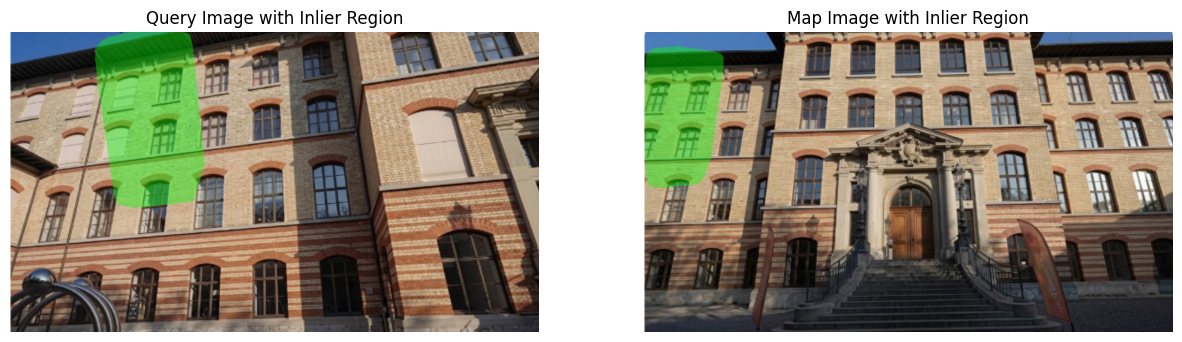

In [59]:
fig, ax = plt.subplots(1,2, figsize=(15,8))
ax[0].imshow(query_vis)
ax[0].set_title("Query Image with Inlier Region")
ax[0].axis('off')
ax[1].imshow(map_vis)
ax[1].set_title("Map Image with Inlier Region")
ax[1].axis('off')
plt.show()

In [60]:
# img_path0 = '/home/robotics/VisualLocalization/DAT/crocodl-benchmark/external/hloc/datasets/sacre_coeur/mapping/03903474_1471484089.jpg'
# img_path1 = '/home/robotics/VisualLocalization/DAT/crocodl-benchmark/external/hloc/datasets/sacre_coeur/mapping/10265353_3838484249.jpg'

img_path0 = "/home/robotics/VisualLocalization/DAT/crocodl-benchmark/external/hloc/datasets/doppelgangers/query_doppelgangers1.jpg"
img_path1 = "/home/robotics/VisualLocalization/DAT/crocodl-benchmark/external/hloc/datasets/doppelgangers/map_doppelgangers1.jpg"

In [61]:
def visualize_matching(res_matches, keypoints_query, keypoints_ref, img_path0, img_path1):
    matches = list(res_matches)
    img0 = get_image(img_path0, interp='cv2_area', resize_max=1024)[0].astype(np.uint8)
    # img0 = cv2.cvtColor(img0, cv2.COLOR_BGR2RGB)
    img1 = get_image(img_path1, interp='cv2_area', resize_max=1024)[0].astype(np.uint8)
    # img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

    h1, w1, _ = img0.shape
    h2, w2, _ = img1.shape
    height = max(h1, h2)
    width = w1 + w2

    combined_img = np.zeros((height, width, 3), dtype=np.uint8)
    combined_img[:h1, :w1] = img0
    combined_img[:h2, w1:w1 + w2] = img1

    for i in range(len(matches)):
        for j in range(len(res_matches[i])):
            if res_matches[i][j] == -1:
                continue
            # Lấy tọa độ keypoints
            pt0 = tuple(keypoints_query[i])
            pt1 = tuple(keypoints_ref[res_matches[i,j]])

            # Dịch tọa độ keypoint ảnh thứ 2 sang bên phải
            pt1_shifted = (pt1[0] + w1, pt1[1])

            color = (0,255,0)
            if res_matches[i][j] == -1:
                color = (255,0,0)

            # Vẽ keypoints
            cv2.circle(combined_img, pt0, 2, color, -1)
            cv2.circle(combined_img, pt1_shifted, 2, color, -1)

            
            # Vẽ đường nối nếu match khác -1
            cv2.line(combined_img, pt0, pt1_shifted, color, 2)

    # --- Hiển thị ---
    plt.figure(figsize=(12, 6))
    plt.imshow(combined_img)
    plt.axis('off')
    plt.show()

    return

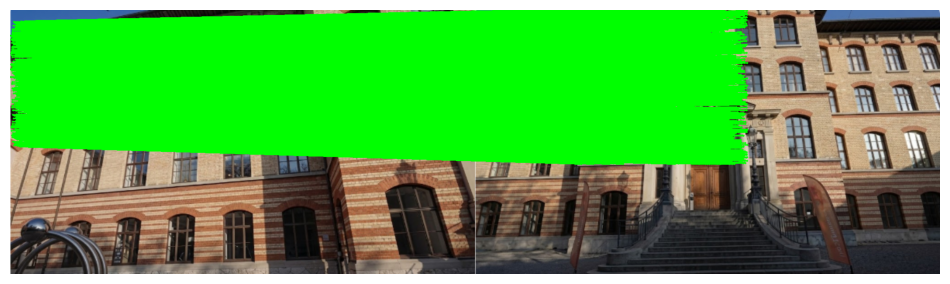

In [63]:
visualize_matching(res_matches, keypoints_ref, keypoints_query, img_path0, img_path1)